# Staphylococcus detached cells project : k-means  labelled t-SNE plot

#### Written by Sydney Packard and ChatGPT 4.0
#### for Stewart Lab use only
#### Email: srpackard@wpi.edu

In [29]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import QuantileTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.decomposition import KernelPCA
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import pairwise_distances
import matplotlib.pyplot as plt
import seaborn as sns

columns = ["N_cl", "Euclid_2R", "Shape_anisotropy_index", "Asphericity_index", "Treatment", "Date"]

file_path = r"Z:\PhD Students\Packard_Sydney\2_Projects and Authored Papers\A_Staphylococcal Dispersed Cells\1_Data Collection and Analysis\Combined_SizeMorphology_Data_v2.xlsx"
data = pd.read_excel(file_path, usecols=columns)
print(len(data))
print(data.head())

9147
   N_cl  Euclid_2R  Shape_anisotropy_index  Asphericity_index  Treatment  \
0    83  20.191787                0.994698          -1.896312      NaIO4   
1    69  15.991678                0.944322          -1.592018      NaIO4   
2    66  12.884921                0.824820          -1.042661      NaIO4   
3    95  11.358946                0.765687           0.452400  Untreated   
4    32  10.605089                0.883816          -1.077022      NaIO4   

         Date  
0  09-28-2023  
1   03-29-024  
2  03-22-2024  
3  09-28-2023  
4   03-29-024  


In [30]:
# Parameters
data_columns = data.columns  # Assume all columns are included initially
exclude_columns = ['Treatment', 'Date']  # List of column names to exclude from z-transform

# Separate excluded columns and apply z-transform
included_columns = [col for col in data_columns if col not in exclude_columns]
#scaler = RobustScaler()
scaler = StandardScaler()
#scaler = PowerTransformer(method="yeo-johnson")
#pca_whiten = PCA(whiten=True)
#scaler = QuantileTransformer(output_distribution='normal', random_state=42)
data_scaled_array = scaler.fit_transform(data[included_columns])  # Scale numeric columns
#whitened_data = pca_whiten.fit_transform(data[included_columns])  # Apply PCA Whitening transformation

# Combine scaled data with the "Treatment" column
treatment_column = data['Treatment'].values.reshape(-1, 1)  # Ensure it is a 2D array
date_column = data['Date'].values.reshape(-1, 1) # Ensure it is a 2D array
data_scaled_combined = np.hstack((data_scaled_array, treatment_column, date_column))

# Create a DataFrame with the original columns
data_scaled = pd.DataFrame(data_scaled_combined, columns=included_columns + exclude_columns)

# Display the original and scaled data for verification
print("Original Data:")
print(data)
print(len(data))

print("\nScaled Data:")
print(data_scaled.head())
print(len(data_scaled))

Original Data:
      N_cl  Euclid_2R  Shape_anisotropy_index  Asphericity_index  Treatment  \
0       83  20.191787                0.994698          -1.896312      NaIO4   
1       69  15.991678                0.944322          -1.592018      NaIO4   
2       66  12.884921                0.824820          -1.042661      NaIO4   
3       95  11.358946                0.765687           0.452400  Untreated   
4       32  10.605089                0.883816          -1.077022      NaIO4   
...    ...        ...                     ...                ...        ...   
9142     1   0.700000                0.000000           0.000000       pH10   
9143     1   0.700000                0.000000           0.000000       pH10   
9144     1   0.700000                0.000000           0.000000       pH10   
9145     1   0.700000                0.000000           0.000000       pH10   
9146     1   0.700000                0.000000           0.000000       pH10   

            Date  
0     09-28-2023 

In [31]:
scaled_data_numerical = data_scaled.drop(["Treatment", "Date"], axis=1)
print(scaled_data_numerical)
data_numerical = data.drop(["Treatment", "Date"], axis = 1) 
print(data_numerical)

           N_cl  Euclid_2R Shape_anisotropy_index Asphericity_index
0     18.912448  16.531836               0.488576         -0.740624
1     15.551754  12.680603               0.327736         -0.405155
2     14.831606   9.831904              -0.053811          0.200487
3     21.793042   8.432682              -0.242612          1.848724
4      6.669923   7.741443                0.13455          0.162605
...         ...        ...                    ...               ...
9142  -0.771612  -1.340896                -2.6873          1.349973
9143  -0.771612  -1.340896                -2.6873          1.349973
9144  -0.771612  -1.340896                -2.6873          1.349973
9145  -0.771612  -1.340896                -2.6873          1.349973
9146  -0.771612  -1.340896                -2.6873          1.349973

[9147 rows x 4 columns]
      N_cl  Euclid_2R  Shape_anisotropy_index  Asphericity_index
0       83  20.191787                0.994698          -1.896312
1       69  15.991678        

In [32]:
print(scaled_data_numerical)

           N_cl  Euclid_2R Shape_anisotropy_index Asphericity_index
0     18.912448  16.531836               0.488576         -0.740624
1     15.551754  12.680603               0.327736         -0.405155
2     14.831606   9.831904              -0.053811          0.200487
3     21.793042   8.432682              -0.242612          1.848724
4      6.669923   7.741443                0.13455          0.162605
...         ...        ...                    ...               ...
9142  -0.771612  -1.340896                -2.6873          1.349973
9143  -0.771612  -1.340896                -2.6873          1.349973
9144  -0.771612  -1.340896                -2.6873          1.349973
9145  -0.771612  -1.340896                -2.6873          1.349973
9146  -0.771612  -1.340896                -2.6873          1.349973

[9147 rows x 4 columns]


In [33]:
numerical_cols = ["N_cl", "Euclid_2R", "Shape_anisotropy_index", "Asphericity_index"]

# Convert numerical columns to float
for col in numerical_cols:
    scaled_data_numerical[col] = pd.to_numeric(scaled_data_numerical[col], errors='coerce')

In [34]:
print(scaled_data_numerical.dtypes)

N_cl                      float64
Euclid_2R                 float64
Shape_anisotropy_index    float64
Asphericity_index         float64
dtype: object


In [35]:
def relabel_clusters_by_size(labels):
    # Count the size of each cluster
    label_counts = pd.Series(labels).value_counts().sort_values(ascending=False)
    label_mapping = {old_label: new_label for new_label, old_label in enumerate(label_counts.index)}
    # Relabel according to cluster size
    new_labels = pd.Series(labels).map(label_mapping).values
    return new_labels

In [36]:
import pandas as pd
import numpy as np

def relabel_clusters_by_size(labels):
    # Count cluster sizes, sorted from largest to smallest
    label_counts = pd.Series(labels).value_counts().sort_values(ascending=False)
    sorted_labels = list(label_counts.index)

    # Custom ordering: [largest, second largest, smallest, third largest, fourth largest]
    order = []
    if len(sorted_labels) >= 1:
        order.append(sorted_labels[0])  # largest
    if len(sorted_labels) >= 2:
        order.append(sorted_labels[1])  # second largest
    if len(sorted_labels) >= 3:
        order.append(sorted_labels[-1]) # smallest
    if len(sorted_labels) >= 4:
        order.append(sorted_labels[2])  # third largest
    if len(sorted_labels) >= 5:
        order.append(sorted_labels[3])  # fourth largest

    # Build mapping old → new
    label_mapping = {old: new for new, old in enumerate(order)}

    # Relabel
    new_labels = pd.Series(labels).map(label_mapping).values
    return new_labels


In [37]:
# K-Means Clustering
n_clusters = 5  # Define the number of clusters
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
#kmeans_labels_unscaled = kmeans.fit_predict(data_numerical)
#kmeans_labels_scaled = kmeans.fit_predict(scaled_data_numerical)

kmeans_labels_unscaled = relabel_clusters_by_size(kmeans.fit_predict(data_numerical))
kmeans_labels_scaled = relabel_clusters_by_size(kmeans.fit_predict(scaled_data_numerical))


c:\Users\spack\anaconda3\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\spack\anaconda3\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [38]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Define custom relabeling function
def relabel_clusters_by_size(labels):
    # Count cluster sizes, sorted from largest to smallest
    label_counts = pd.Series(labels).value_counts().sort_values(ascending=False)
    sorted_labels = list(label_counts.index)

    # Custom ordering: [largest, second largest, smallest, third largest, fourth largest]
    order = []
    if len(sorted_labels) >= 1:
        order.append(sorted_labels[0])  # largest
    if len(sorted_labels) >= 2:
        order.append(sorted_labels[1])  # second largest
    if len(sorted_labels) >= 3:
        order.append(sorted_labels[-1]) # smallest
    if len(sorted_labels) >= 4:
        order.append(sorted_labels[2])  # third largest
    if len(sorted_labels) >= 5:
        order.append(sorted_labels[3])  # fourth largest

    # Build mapping old → new
    label_mapping = {old: new for new, old in enumerate(order)}

    # Relabel
    new_labels = pd.Series(labels).map(label_mapping).values
    return new_labels

# 2. Load the data
columns = ["N_cl", "Euclid_2R", "Shape_anisotropy_index", "Asphericity_index", "Treatment", "Date"]
file_path = r"Z:\PhD Students\Packard_Sydney\2_Projects and Authored Papers\A_Staphylococcal Dispersed Cells\1_Data Collection and Analysis\Combined_SizeMorphology_Data_v2.xlsx"
data = pd.read_excel(file_path, usecols=columns)

# 3. Clean the data (ensure numerical cols are floats and drop NaNs early for alignment)
numerical_cols = ["N_cl", "Euclid_2R", "Shape_anisotropy_index", "Asphericity_index"]
for col in numerical_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Drop missing values and reset index so alignment stays perfect
data = data.dropna().reset_index(drop=True)

# 4. Scale the numerical data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(data[numerical_cols])
scaled_data_numerical = pd.DataFrame(scaled_features, columns=numerical_cols)

# 5. Apply K-Means Clustering
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)

# Predict and relabel
kmeans_labels_scaled = relabel_clusters_by_size(kmeans.fit_predict(scaled_data_numerical))

# 6. Add labels back to the main dataframe
data['Cluster'] = kmeans_labels_scaled

# ---------------------------------------------------------
# NEW CODE: Count clusters per treatment and date
# ---------------------------------------------------------

# Option A: A standard grouped list
print("\n--- Cluster Counts (List Format) ---")
cluster_counts = data.groupby(['Treatment', 'Date', 'Cluster']).size().reset_index(name='Count')
print(cluster_counts)

# Option B: A Pivot Table (Usually much easier to read)
print("\n--- Cluster Counts (Pivot Table Format) ---")
pivot_counts = data.pivot_table(
    index=['Treatment', 'Date'], 
    columns='Cluster', 
    aggfunc='size', 
    fill_value=0 # Fills in 0 if a treatment/date combo is missing a specific cluster
)
print(pivot_counts)

# Optional: Save the pivoted counts to a new Excel file
# pivot_counts.to_excel("Cluster_Counts_Summary.xlsx")


--- Cluster Counts (List Format) ---
   Treatment        Date  Cluster  Count
0     DNaseI  04-23-2024        0    446
1     DNaseI  04-23-2024        1     95
2     DNaseI  04-23-2024        2      2
3     DNaseI  04-23-2024        3     64
4     DNaseI  04-23-2024        4     57
..       ...         ...      ...    ...
90      pH10  05-21-2024        4     30
91      pH10  10-06-2023        0    118
92      pH10  10-06-2023        1     42
93      pH10  10-06-2023        3     15
94      pH10  10-06-2023        4     25

[95 rows x 4 columns]

--- Cluster Counts (Pivot Table Format) ---
Cluster                  0    1   2    3    4
Treatment Date                               
DNaseI    04-23-2024   446   95   2   64   57
          04-24-2024   197   46   2   37   22
          05-10-2024   439  109   2   48   50
          05-16-2024   175   32   0   18   28
NaIO4     03-22-2024   284   98  22   80   30
          03-29-024    568  209  49  144   80
          05-14-2024   528  131   

c:\Users\spack\anaconda3\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [39]:
# ---------------------------------------------------------
# EXPORT TO EXCEL
# ---------------------------------------------------------
output_file_path = r"Z:\PhD Students\Packard_Sydney\2_Projects and Authored Papers\A_Staphylococcal Dispersed Cells\1_Data Collection and Analysis\Cluster_Counts_Summary.xlsx"

# Use ExcelWriter to save multiple dataframes to different sheets
with pd.ExcelWriter(output_file_path, engine='openpyxl') as writer:
    # Save the easy-to-read pivot table to the first sheet
    pivot_counts.to_excel(writer, sheet_name='Pivot Table Counts')
    
    # Save the flat list to the second sheet (ignoring the auto-generated index)
    cluster_counts.to_excel(writer, sheet_name='List Format Counts', index=False)

print(f"\nSuccessfully exported cluster counts to: {output_file_path}")


Successfully exported cluster counts to: Z:\PhD Students\Packard_Sydney\2_Projects and Authored Papers\A_Staphylococcal Dispersed Cells\1_Data Collection and Analysis\Cluster_Counts_Summary.xlsx


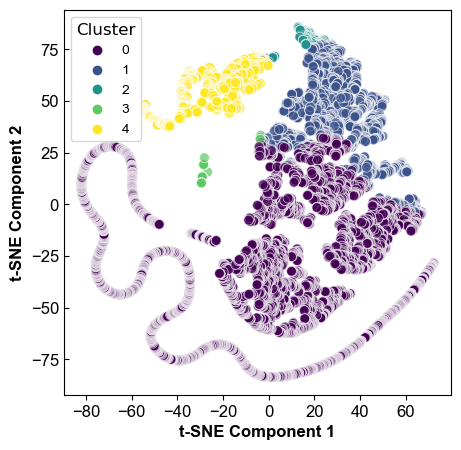

In [40]:
# Visualization using t-SNE on unscaled, scaled, and KPCA-transformed data
#tsne = TSNE(n_components=2, random_state=42, perplexity=15.0)

# Apply t-SNE to the unscaled data
#data_tsne_unscaled = tsne.fit_transform(data_numerical)
#tsne_unscaled_df = pd.DataFrame(data_tsne_unscaled, columns=['t-SNE1', 't-SNE2'])

# Apply t-SNE to the scaled data
tsne = TSNE(n_components=2, random_state=42, early_exaggeration=20, learning_rate='auto', perplexity=30)  # New instance for scaled data
data_tsne_scaled = tsne.fit_transform(scaled_data_numerical)
tsne_scaled_df = pd.DataFrame(data_tsne_scaled, columns=['t-SNE1', 't-SNE2'])

# Apply t-SNE to the kPCA-transformed data
#tsne = TSNE(n_components=2, random_state=42)  # New instance for kPCA data
#data_tsne_kpca = tsne.fit_transform(data_kpca_numerical)
#tsne_kpca_df = pd.DataFrame(data_tsne_kpca, columns=['t-SNE1', 't-SNE2'])

# Plotting the unscaled data with unscaled labels
#plt.figure(figsize=(4, 4))
#sns.scatterplot(data=tsne_unscaled_df, x='t-SNE1', y='t-SNE2', hue=kmeans_labels_unscaled, palette='viridis', s=50, alpha=0.7)
#plt.title('t-SNE Visualization of Unscaled Data', fontsize=12, fontname="Arial", fontweight="bold")
#plt.xlabel('t-SNE Component 1', fontsize=12, fontname="Arial", fontweight="bold")
#plt.ylabel('t-SNE Component 2', fontsize=12, fontname="Arial", fontweight="bold")
#plt.xticks(fontsize=12, fontname='Arial')
#plt.yticks(fontsize=12, fontname='Arial')
#plt.tick_params(axis='y', direction='in', labelright=False, labelleft=True)
#plt.legend(title='Cluster', fontsize=12, title_fontsize=12, prop={'family': 'Arial'})
#plt.savefig(r"C:\Users\spack\OneDrive - Worcester Polytechnic Institute (wpi.edu)\Documents\Grad\Stewart_Lab\PAPERS\Staphylococcal Dispersed Cells\Plots\t-SNE Visualization of Unscaled Data with Unscaled Labels_k3_v6.jpeg", dpi=300, bbox_inches="tight")
#plt.show()

# Plotting the scaled data with scaled labels
plt.figure(figsize=(5, 5))
sns.scatterplot(data=tsne_scaled_df, x='t-SNE1', y='t-SNE2', hue=kmeans_labels_scaled, palette='viridis', s=50, alpha=0.7)
#plt.title('t-SNE Visualization of Z-Transform Scaled Data', fontsize=12, fontname="Arial", fontweight="bold")
plt.xlabel('t-SNE Component 1', fontsize=12, fontname="Arial", fontweight="bold")
plt.ylabel('t-SNE Component 2', fontsize=12, fontname="Arial", fontweight="bold")
plt.xticks(fontsize=12, fontname='Arial')
plt.yticks(fontsize=12, fontname='Arial')
plt.tick_params(axis='y', direction='in', labelright=False, labelleft=True)
plt.legend(title='Cluster', fontsize=12, title_fontsize=12, prop={'family': 'Arial'})
plt.show()

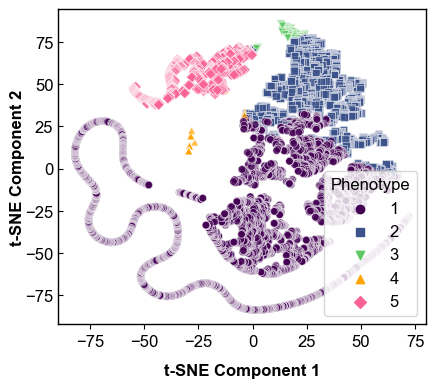

In [41]:
fig = plt.figure(figsize=(5.25, 4.5))  # 5" wide, 3.57" tall to make axes 2.5" high
ax = fig.add_axes([0.15, 0.15, 0.7, 0.7])  # Axes takes 70% of figure height

custom_palette = [
    (0.267004, 0.004874, 0.329415),  # dark purple
    (0.229739, 0.322361, 0.545706),  # blue
    (0.369214, 0.788888, 0.382914),  # green
    (255/255, 165/255, 0/255), #orange
    (249/255, 100/255, 149/255)  # pink
    # pink (instead of yellow)    
    
]

sns.scatterplot(
    data=tsne_scaled_df, x='t-SNE1', y='t-SNE2',
    hue=kmeans_labels_scaled,
    style=kmeans_labels_scaled,
    markers={0: 'o', 1: 's', 2: 'v', 3: '^', 4: 'D'},
    palette=custom_palette, s=30, alpha=0.7, ax=ax
)

# Get all handles and labels from the legend
handles, labels = ax.get_legend_handles_labels()

# Keep only numeric labels and their corresponding handles
cluster_items = [(h, int(l)) for h, l in zip(handles, labels) if l.isdigit()]

# Sort by cluster number (just in case)
cluster_items.sort(key=lambda x: x[1])

# Shift labels from 0-based to 1-based
new_handles = [h for h, _ in cluster_items]
new_labels = [str(i + 1) for _, i in cluster_items]

legend = ax.legend(
    handles=new_handles,
    labels=new_labels,
    title='Phenotype',
    loc="lower right",
    title_fontsize=12,
    prop={'family': 'Arial', 'size': 12}
)


# Now you can set the font name of the legend title
legend.get_title().set_fontname('Arial')

# Set axis labels
ax.set_xlabel('t-SNE Component 1', fontsize=12, fontname="Arial", fontweight="bold", labelpad=10)
ax.set_ylabel('t-SNE Component 2', fontsize=12, fontname="Arial", fontweight="bold", labelpad=0)
plt.xticks(fontsize=12, fontname='Arial')
plt.yticks(fontsize=12, fontname='Arial')

# Set tick formatting
ax.tick_params(axis='y', direction='in', labelright=False, labelleft=True)

# Set spine linewidth to 1 pt
for spine in ax.spines.values():
    spine.set_linewidth(1)

# Legend
#ax.legend(title='Cluster', fontsize=12, title_fontsize=12, prop={'family': 'Arial'})

# Save and show
plt.savefig(r"Z:\PhD Students\Packard_Sydney\2_Projects and Authored Papers\A_Staphylococcal Dispersed Cells\07_Staph Dispersed Cells Figures\Plots\t-SNE Visualization of Scaled Data_k5_perplexity30.jpeg", dpi=300, bbox_inches="tight")
plt.show()